# Autonomous USV Path Planning: Exploring RRT and RRT*

Welcome to this training session on sampling-based path planning. In this assignment, you will explore how autonomous vehicles navigate through environments with obstacles.

We will focus on two foundational algorithms:
1. **Rapidly-exploring Random Tree (RRT):** A fast, heavily randomized algorithm that efficiently searches high-dimensional spaces but often yields jagged, suboptimal paths.
2. **RRT\* (Optimal RRT):** An extension of RRT that constantly "rewires" its tree to find shorter, more efficient paths, though at a higher computational cost.

---
## Part 1: The Algorithms (Pseudocode)

Before diving into the Python code, review the pseudocode below. Full paper is here: https://arxiv.org/pdf/1105.1186 (page 13-16)

### 1. Standard RRT Algorithm

The standard RRT builds a tree from the start node by randomly sampling points in the space and extending the tree toward those points.

![](https://drive.google.com/uc?export=view&id=1SFcWGdn_QdXeEBInalNFWgZIbLLHl9pj)
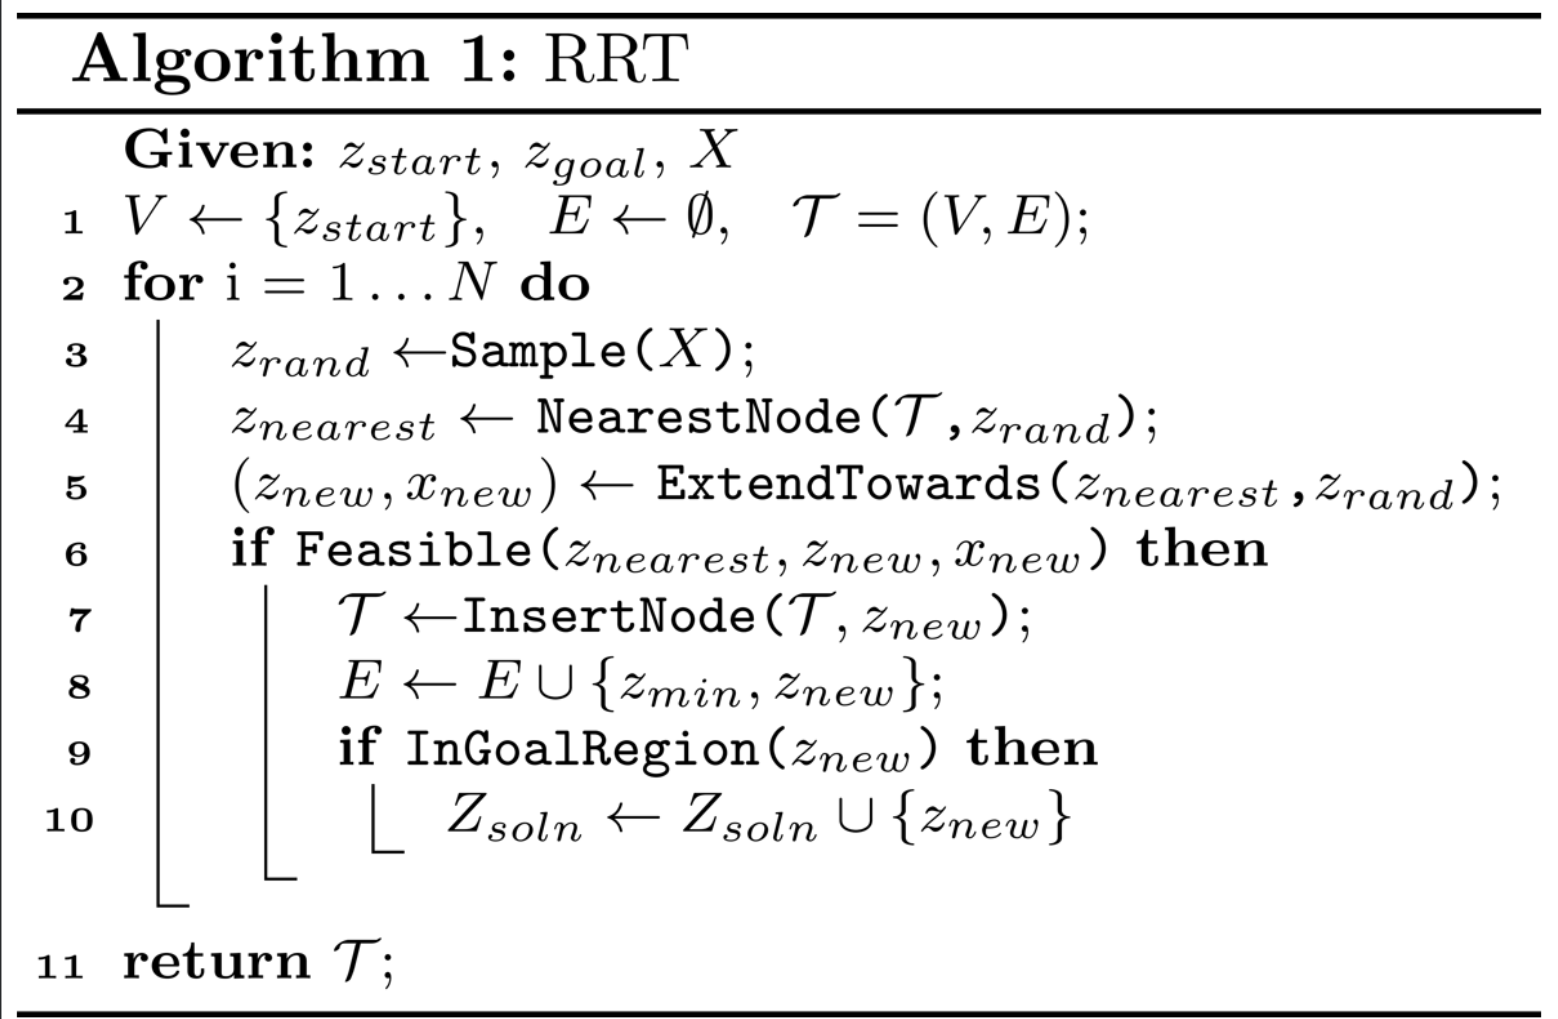

### 2. RRT* Algorithm

RRT* improves upon RRT by keeping track of the "cost" (distance traveled from the start) and rewiring the tree to ensure nodes are connected via the shortest possible path.

![](https://drive.google.com/uc?export=view&id=1Pyo5XqWRWfpMVepHL_oj23eQXqek68Eq)
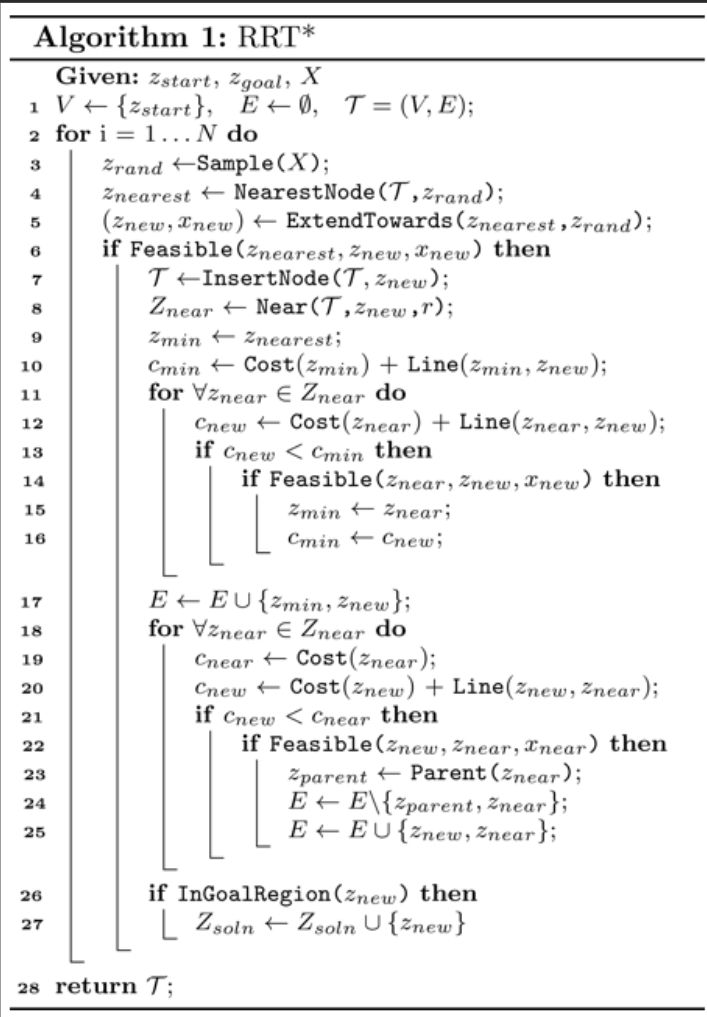


# Implement the missing code

Notice that several critical steps are missing (`[TODO]`). You will need to apply your understanding of RRT and RRT* to complete the actual Python implementation in the code cells below.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

class Node:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.parent = None

def get_distance(n1: Node, n2: Node) -> float:
    return np.sqrt((n1.x - n2.x)**2 + (n1.y - n2.y)**2)

def is_segment_collision_free(p1, p2, obstacles):
    """
    Checks if the line segment between p1 and p2 intersects any circular obstacle.
    """
    p1, p2 = (p1.x, p1.y), (p2.x, p2.y)
    for (ox, oy, r) in obstacles:
        center = np.array([ox, oy])
        a = np.array(p1)
        b = np.array(p2)

        # Vector from A to B and A to Center
        ab = b - a
        ac = center - a

        # Project ac onto ab to find the closest point on the line
        # clamp t to [0, 1] to stay on the segment
        t = np.dot(ac, ab) / np.dot(ab, ab)
        t = max(0, min(1, t))

        closest_point = a + t * ab
        dist_to_circle = np.linalg.norm(closest_point - center)

        if dist_to_circle < r:
            return False # Collision detected
    return True

def random_sampling_node(bounds: tuple) -> Node:
    # TODO: Implement the random sampling node
    min_x, max_x, min_y, max_y = bounds
    x = np.random.uniform(min_x, max_x)
    y = np.random.uniform(min_y, max_y)
    return Node(x, y)

def get_nearest_node(tree: list[Node], node: Node) -> Node:
    # TODO: Implement to get nearest node
    return min(tree, key=lambda n: get_distance(n, node))

def construct_path(node: Node) -> list[Node]:
    # TODO: Implement to condruct path from start to goal
    path = []
    current = node
    while current is not None:
        path.append(current)
        current = current.parent
    path.reverse()
    return path

def rrt(start: tuple, goal: tuple, obstacles: list[tuple], bounds: tuple, step_size: float=0.5, max_iter: int=3000) -> list[Node]:
    """
    start: (x, y)
    goal: (x, y, radius)
    bounds: (min_x, max_x, min_y, max_y)
    """
    tree = [Node(start[0], start[1])]
    goal_node = Node(goal[0], goal[1])
    goal_radius = goal[2]

    for i in range(max_iter):
        # 1. Sample
        random_node = random_sampling_node(bounds)

        # 2. Nearest Node
        nearest_node = get_nearest_node(tree, random_node)

        # 3. Extend Towards
        theta = np.arctan2(random_node.y - nearest_node.y, random_node.x - nearest_node.x)
        new_x = nearest_node.x + step_size * np.cos(theta)
        new_y = nearest_node.y + step_size * np.sin(theta)
        new_node = Node(new_x, new_y)

        # 4. Segment Collision Check
        if is_segment_collision_free(nearest_node, new_node, obstacles):
            new_node.parent = nearest_node
            tree.append(new_node)

            # 5. Goal check
            if get_distance(new_node, goal_node) <= goal_radius:
                return construct_path(new_node)

    return None

def get_nearby_nodes(tree: list[Node], node: Node, search_radius: float) -> list[Node]:
    # TODO: Implement to get nearby nodes within search radius
    return [n for n in tree if get_distance(n, node) <= search_radius]

def get_best_parent(nearby_nodes: list[Node], nearest_node: Node, new_node: Node, obstacles: tuple) -> tuple[Node, float]:
    # TODO: Implement to get best parent among nearby nodes
    best_parent = nearest_node
    min_cost = nearest_node.cost + get_distance(nearest_node, new_node)

    for near_node in nearby_nodes:
        if is_segment_collision_free(near_node, new_node, obstacles):
            candidate_cost = near_node.cost + get_distance(near_node, new_node)
            if candidate_cost < min_cost:
                min_cost = candidate_cost
                best_parent = near_node

    return best_parent, min_cost

def rrt_star(start: tuple, goal: tuple, obstacles: list[tuple], bounds: tuple, step_size: float=0.5, max_iter: int=3000, search_radius: float=1.5) -> list[Node]:
    """
    start: (x, y)
    goal: (x, y, radius)
    bounds: (min_x, max_x, min_y, max_y)
    search_radius: radius to look for neighboring nodes for rewiring
    """
    start_node = Node(start[0], start[1])
    start_node.cost = 0.0 # Ensure your Node class supports cost tracking
    tree = [start_node]
    goal_node = Node(goal[0], goal[1])
    goal_radius = goal[2]

    best_goal_node = None

    for i in range(max_iter):
        # 1. Sample
        random_node = random_sampling_node(bounds)

        # 2. Nearest Node
        nearest_node = get_nearest_node(tree, random_node)

        # 3. Extend Towards
        theta = np.arctan2(random_node.y - nearest_node.y, random_node.x - nearest_node.x)
        new_x = nearest_node.x + step_size * np.cos(theta)
        new_y = nearest_node.y + step_size * np.sin(theta)
        new_node = Node(new_x, new_y)

        # 4. Check if the initial step is collision-free
        if is_segment_collision_free(nearest_node, new_node, obstacles):
            # Find all nearby nodes within the search radius
            nearby_nodes = get_nearby_nodes(tree, new_node, search_radius)

            # --- RRT* STEP A: Choose Best Parent ---
            best_parent, min_cost = get_best_parent(nearby_nodes, nearest_node, new_node, obstacles)
            new_node.parent = best_parent
            new_node.cost = min_cost
            tree.append(new_node)

            # --- RRT* STEP B: Rewire the Tree ---
            # TODO: Implement to rewire the tree
            for near_node in nearby_nodes:
                if near_node is best_parent:
                    continue
                if is_segment_collision_free(new_node, near_node, obstacles):
                    new_cost = new_node.cost + get_distance(new_node, near_node)
                    if new_cost < near_node.cost:
                        near_node.parent = new_node
                        near_node.cost = new_cost

            # 5. Goal check (Track the best path instead of returning immediately)
            if get_distance(new_node, goal_node) <= goal_radius:
                if best_goal_node is None or new_node.cost < best_goal_node.cost:
                    best_goal_node = new_node

    # 6. Extract the best path found after all iterations
    if best_goal_node:
        return construct_path(best_goal_node)

    return None

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time
from python_vehicle_simulator.vehicles import otter
from python_vehicle_simulator.lib import attitudeEuler

def run_path_planning(path_planning_method = "RRT", # RRT or RRT*
                      guidance_strategy = "CB", # CB, PP, or LOS
                      start_point = (0.0,-20.0), # (x, y)
                      goal_region = (200, 200, 10.0), # (x, y, radius)
                      bounds = (-25, 225, -25, 225), # (min_x, max_x, min_y, max_y)
                      obstacles = [(80, 80, 30), (50, 120, 30), (150, 100, 28)], # list of circle (x_center,y_center,radius)
                      step_size = 20.0, # Parameter for RRT and RRT*
                      search_radius = 50.0, # Parameter for RRT*
                      radius_acceptance = 15.0,
                      lookahead_distance = 20.0, # Parameter for guidance
                      kappa = 2.5, # Parameter for CB
                      sim_time = 1200.0, # Increase simulation time to complete the path following
                      sampleTime = 0.05,
                      ):
    def sawtooth(x):
        return 2 * np.arctan(np.tan(x / 2))

    # --- 1. OTTER USV CONTROLLER ---
    class myOtter(otter):
        def __init__(self, controlSystem, u_d, V_current, beta_current):
            mycontrolSystem = str(controlSystem)
            super().__init__(controlSystem, 0, V_current, beta_current, 0)
            self.D2R = np.pi / 180
            if mycontrolSystem == "my_controller":
                self.u_d = u_d
                self.a_d = 0
                self.r_d = 0
                self.e_u_int = 0
                self.e_psi_int = 0
                self.controlMode = mycontrolSystem

        def my_controller(self, eta, nu, ref, sampleTime):
            psi, r, u = eta[5], nu[5], nu[0]
            u_d, psi_d, r_d = ref[0], ref[1], ref[2]

            e_psi = sawtooth(psi - psi_d)
            e_r = r - r_d
            e_u = u - u_d

            self.e_u_int += e_u * sampleTime
            self.e_psi_int += e_psi * sampleTime

            # Tuned Gains
            Kpu, Kiu = 150., 10.
            Kpy, Kiy, Kdy = 50.0, 0.1, 20.0

            tau_X = -Kpu * e_u - Kiu * self.e_u_int
            tau_N = -Kpy * e_psi - Kiy * self.e_psi_int - Kdy * e_r

            tau = np.array([tau_X, tau_N])
            u_alloc = np.matmul(self.Binv, tau)

            n_left = np.sign(u_alloc[0]) * math.sqrt(abs(u_alloc[0]))
            n_right = np.sign(u_alloc[1]) * math.sqrt(abs(u_alloc[1]))

            return np.array([n_left, n_right], float), e_u, e_psi, 0

    # --- 2. SIMULATION FUNCTION ---
    def simulate_path_planning(N, sampleTime, vehicle, strategy="CB"):
        DOF = 6
        eta = np.array([start_point[0], start_point[1], 0, 0, 0, 0], float) # Start slightly off-path
        nu = vehicle.nu
        u_actual = vehicle.u_actual
        simData = np.empty([0, 2 * DOF + 2 * vehicle.dimU], float)

        print(f"Path planning starts...")
        path_planning_start_time = time.perf_counter()

        if path_planning_method == "RRT*":
            path = np.array(rrt_star(start_point, goal_region, obstacles, bounds, step_size = step_size, search_radius = search_radius))
        else: # RRT
            path = np.array(rrt(start_point, goal_region, obstacles, bounds, step_size = step_size))

        path_planning_end_time = time.perf_counter()
        path_planning_duration = path_planning_end_time - path_planning_start_time
        print(f"Path planning execution time: {path_planning_duration:.6f} seconds")

        waypoints = []
        for i in range(len(path)):
            waypoints.append([path[i].x, path[i].y])
        waypoints = np.array(waypoints)

        wp_idx = 0
        R_accept = radius_acceptance # Circle of acceptance to switch to next waypoint
        Delta = lookahead_distance # Lookahead distance

        for i in range(0, N + 1):
            t = i * sampleTime
            pr = np.array([eta[0], eta[1]], float)

            # Waypoint Switching Logic
            if wp_idx < len(waypoints) - 1:
                p_k = waypoints[wp_idx]
                p_k_next = waypoints[wp_idx + 1]

                # Distance to the NEXT waypoint
                dist_to_next = np.linalg.norm(pr - p_k_next)
                if dist_to_next < R_accept:
                    wp_idx += 1
                    if wp_idx >= len(waypoints) - 1:
                        # End of path reached
                        u_d = 0.0
                        psi_d = eta[5]
                        continue
            else:
                p_k = waypoints[-2]
                p_k_next = waypoints[-1]

            # Path Geometry
            alpha = np.arctan2(p_k_next[1] - p_k[1], p_k_next[0] - p_k[0])

            # Cross-track error (e_y) and along-track distance (s)
            e_y = -(pr[0] - p_k[0]) * np.sin(alpha) + (pr[1] - p_k[1]) * np.cos(alpha)
            s = (pr[0] - p_k[0]) * np.cos(alpha) + (pr[1] - p_k[1]) * np.sin(alpha)

            # Base desired speed
            u_d = vehicle.u_d if wp_idx < len(waypoints) - 1 else 0.0

            # --- GUIDANCE STRATEGIES ---
            if strategy == "LOS":
                # Line-of-Sight Path Following
                psi_d = alpha + np.arctan(-e_y / Delta)

            elif strategy == "PP":
                # Pure Pursuit (Aiming at a virtual point Delta meters ahead on path)
                p_target = p_k + (s + Delta) * np.array([np.cos(alpha), np.sin(alpha)])
                psi_d = np.arctan2(p_target[1] - pr[1], p_target[0] - pr[0])

            elif strategy == "CB":
                # Constant Bearing (Chasing a virtual target moving along the path)
                p_target = p_k + (s + Delta) * np.array([np.cos(alpha), np.sin(alpha)])
                v_target = u_d * np.array([np.cos(alpha), np.sin(alpha)]) # Target velocity vector

                p_tilde = pr - p_target
                dist_t = np.linalg.norm(p_tilde)

                if dist_t > 0.1:
                    v_a = -kappa * (p_tilde / dist_t)
                    v_d = v_target + v_a
                    psi_d = np.arctan2(v_d[1], v_d[0])
                else:
                    psi_d = alpha

            r_d = 0.0
            z_d = vehicle.z_d if hasattr(vehicle, 'z_d') else 0

            # Apply to Controller
            ref = np.array([u_d, psi_d, r_d, z_d], float)
            u_control, e_u, e_yaw, e_z = vehicle.my_controller(eta, nu, ref, sampleTime)

            # Store data & Propagate dynamics
            signals = np.append(np.append(np.append(eta, nu), u_control), u_actual)
            simData = np.vstack([simData, signals])

            nu, u_actual = vehicle.dynamics(eta, nu, u_actual, u_control, sampleTime)
            eta = attitudeEuler(eta, nu, sampleTime)

        simTime = np.arange(start=0, stop=t + sampleTime, step=sampleTime)[:, None]
        return simTime, simData, waypoints, obstacles, path_planning_duration

    # --- 3. RUN AND PLOT ---
    N = int(sim_time / sampleTime)

    otter_usv = myOtter("my_controller", u_d=1.0, V_current=0., beta_current=0.)

    plt.figure(figsize=(10, 8))

    simTime, simData, WPs, obstacles, path_planning_duration = simulate_path_planning(N, sampleTime, otter_usv, strategy=guidance_strategy)
    plt.plot(simData[:, 0], simData[:, 1], linewidth=2, label=f'Guidance: {guidance_strategy}')

    # Plot the geometric path
    wp_x = WPs[:, 0]
    wp_y = WPs[:, 1]
    plt.plot(wp_x, wp_y, 'k--', linewidth=2, label='Desired Path')

    # Plot waypoints
    plt.scatter(wp_x, wp_y, c='k', marker='o', s=80, zorder=5, label='Waypoints')
    plt.scatter(start_point[0], start_point[1], c='magenta', marker='s', s=100, zorder=5, label='USV Start')

    # Draw Circles of Acceptance around waypoints
    ax = plt.gca()
    for i in range(1, len(WPs)-1):
        circle = plt.Circle((WPs[i, 0], WPs[i, 1]), radius_acceptance, color='gray', fill=False, linestyle=':')
        ax.add_patch(circle)

    # Draw obstacles
    for obstacle in obstacles:
        x_c, y_c, r = obstacle
        circle = plt.Circle((x_c, y_c), r, color='black', fill=True, linewidth=2)
        ax.add_patch(circle)

    plt.title("Path planning with "+path_planning_method+" with "+guidance_strategy+" guidance")
    plt.xlabel("X (North) [m]")
    plt.ylabel("Y (East) [m]")
    plt.grid(True)
    plt.axis('equal')
    plt.legend()
    plt.show()

    return simTime, simData, WPs, obstacles, path_planning_duration

Path planning starts...
Path planning execution time: 0.026683 seconds


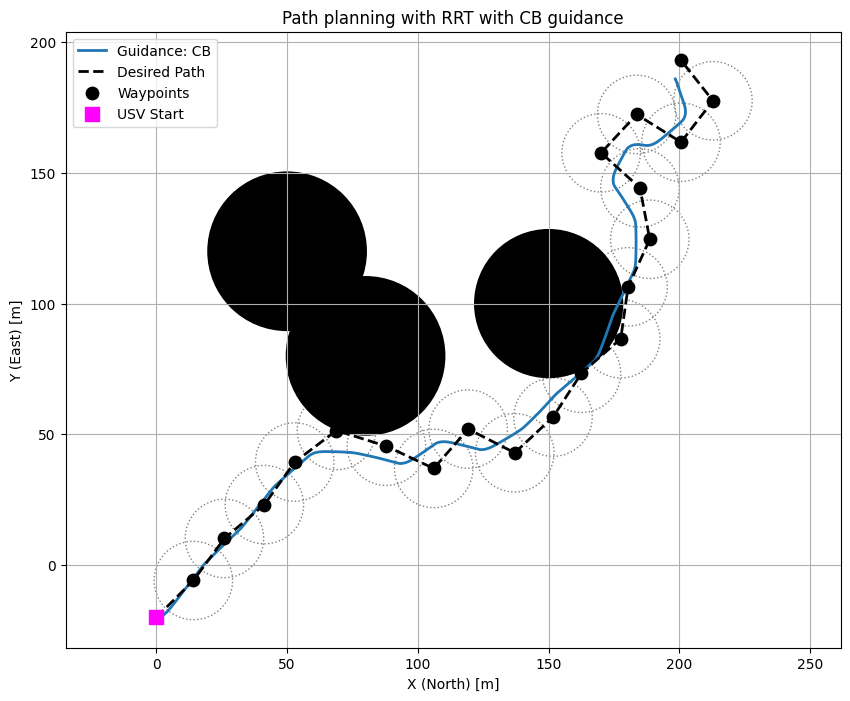

In [8]:
simTime, simData, WPs, obstacles, path_planning_duration = \
  run_path_planning(path_planning_method = "RRT", # RRT or RRT*
                      guidance_strategy = "CB", # CB, PP, or LOS
                      start_point = (0.0,-20.0), # (x, y)
                      goal_region = (200, 200, 10.0), # (x, y, radius)
                      bounds = (-25, 225, -25, 225), # (min_x, max_x, min_y, max_y)
                      obstacles = [(80, 80, 30), (50, 120, 30), (150, 100, 28)], # list of circle (x_center,y_center,radius)
                      step_size = 20.0, # Parameter for RRT and RRT*
                      search_radius = 50.0, # Parameter for RRT*
                      radius_acceptance = 15.0,
                      lookahead_distance = 20.0, # Parameter for guidance
                      kappa = 2.5, # Parameter for CB
                      sim_time = 1200.0, # Increase simulation time to complete the path following
                      sampleTime = 0.05,
                      )

Path planning starts...
Path planning execution time: 24.710470 seconds


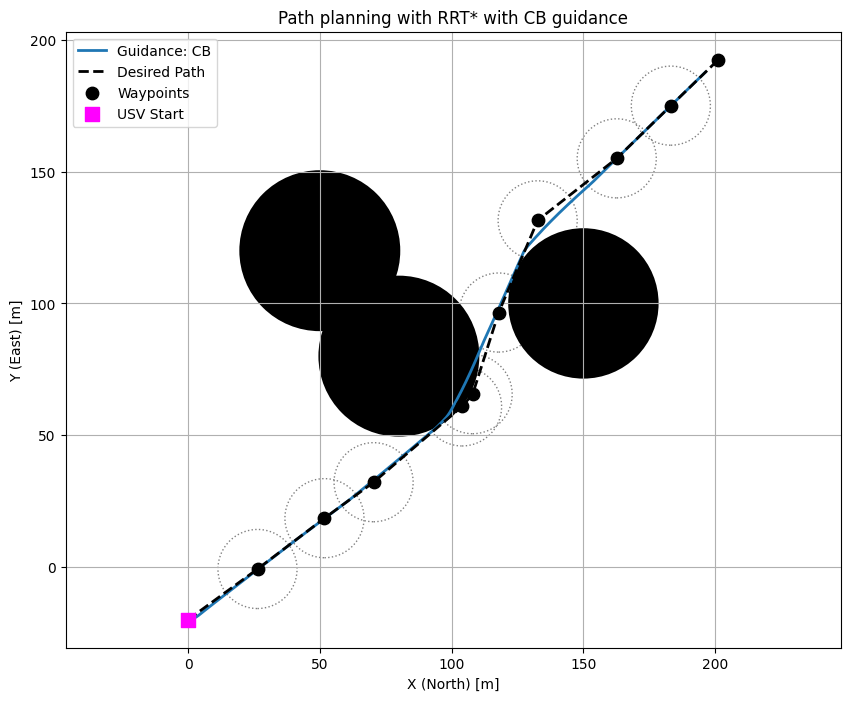

In [9]:
simTime, simData, WPs, obstacles, path_planning_duration = \
  run_path_planning(path_planning_method = "RRT*", # RRT or RRT*
                      guidance_strategy = "CB", # CB, PP, or LOS
                      start_point = (0.0,-20.0), # (x, y)
                      goal_region = (200, 200, 10.0), # (x, y, radius)
                      bounds = (-25, 225, -25, 225), # (min_x, max_x, min_y, max_y)
                      obstacles = [(80, 80, 30), (50, 120, 30), (150, 100, 28)], # list of circle (x_center,y_center,radius)
                      step_size = 20.0, # Parameter for RRT and RRT*
                      search_radius = 50.0, # Parameter for RRT*
                      radius_acceptance = 15.0,
                      lookahead_distance = 20.0, # Parameter for guidance
                      kappa = 2.5, # Parameter for CB
                      sim_time = 1200.0, # Increase simulation time to complete the path following
                      sampleTime = 0.05,
                      )

# Analysis

### 1. The price of optimality

Run both the standard RRT and RRT* algorithms using the default parameters provided in the script. You will notice a difference in both the execution time and the geometric shape of the path. Why RRT* takes longer to compute?

### 2. Algorithmic Consistency and Randomness

Because both algorithms rely on random sampling, running the same code five times will yield five different paths. Run the standard RRT algorithm 5 separate times and plot/save the results. How drastically does the path change between runs? Does the execution time fluctuate?

### 3. Implementing Goal Bias

Look closely at the `random_sampling_node` function. Currently, it samples points uniformly across the entire simulation boundary. This means the algorithm searches completely blindly.

Rewrite the `random_sampling_node` function to accept two new parameters: `goal_node` and `goal_bias_prob`. Modify the logic so that with a probability of `goal_bias_prob` (e.g., 10%), the function returns the exact coordinates of the goal instead of a random point.
Run standard RRT with a goal bias of 0% (default), 5%, 20%, and 80%.

How does increasing the goal bias affect the execution time? What happens to the success rate and path shape when the goal bias is set too high (like 80%) in an environment with complex obstacles?

### 4. The Kinematic vs Dynamic Gap

The RRT and RRT* planners in this code are kinematic—they assume the vehicle is a point mass that can move in any direction instantly. However, the simulation uses a dynamic controller that obeys the laws of physics.

How does this discrepancy affect the vehicle's ability to stay inside the radius_acceptance at each waypoint?

If you were tasked with modifying the path planning phase (RRT/RRT*) so that it generates paths the Otter USV can follow more easily, what constraints would you add to the `is_segment_collision_free` or `Extend Towards` steps?

RRT goal-bias experiment over 5 runs per bias


,goal_bias,run,success,time_s,path_length_m,num_waypoints
0,0.00,1,True,0.021,460.0,24
1,0.00,2,True,0.014,400.0,21
2,0.00,3,True,0.015,440.0,23
3,0.00,4,True,0.006,400.0,21
4,0.00,5,True,0.036,380.0,20
5,0.05,1,True,0.007,360.0,19
6,0.05,2,True,0.007,360.0,19
7,0.05,3,True,0.006,360.0,19
8,0.05,4,True,0.007,360.0,19
9,0.05,5,True,0.010,440.0,23


Summary


,goal_bias,success_rate,avg_time_s,std_time_s,avg_path_length_m,avg_waypoints
0,0.00,100.0,0.018,0.011,416.0,21.8
1,0.05,100.0,0.007,0.002,376.0,19.8
2,0.20,100.0,0.004,0.001,400.0,21.0
3,0.80,100.0,0.006,0.005,376.0,19.8


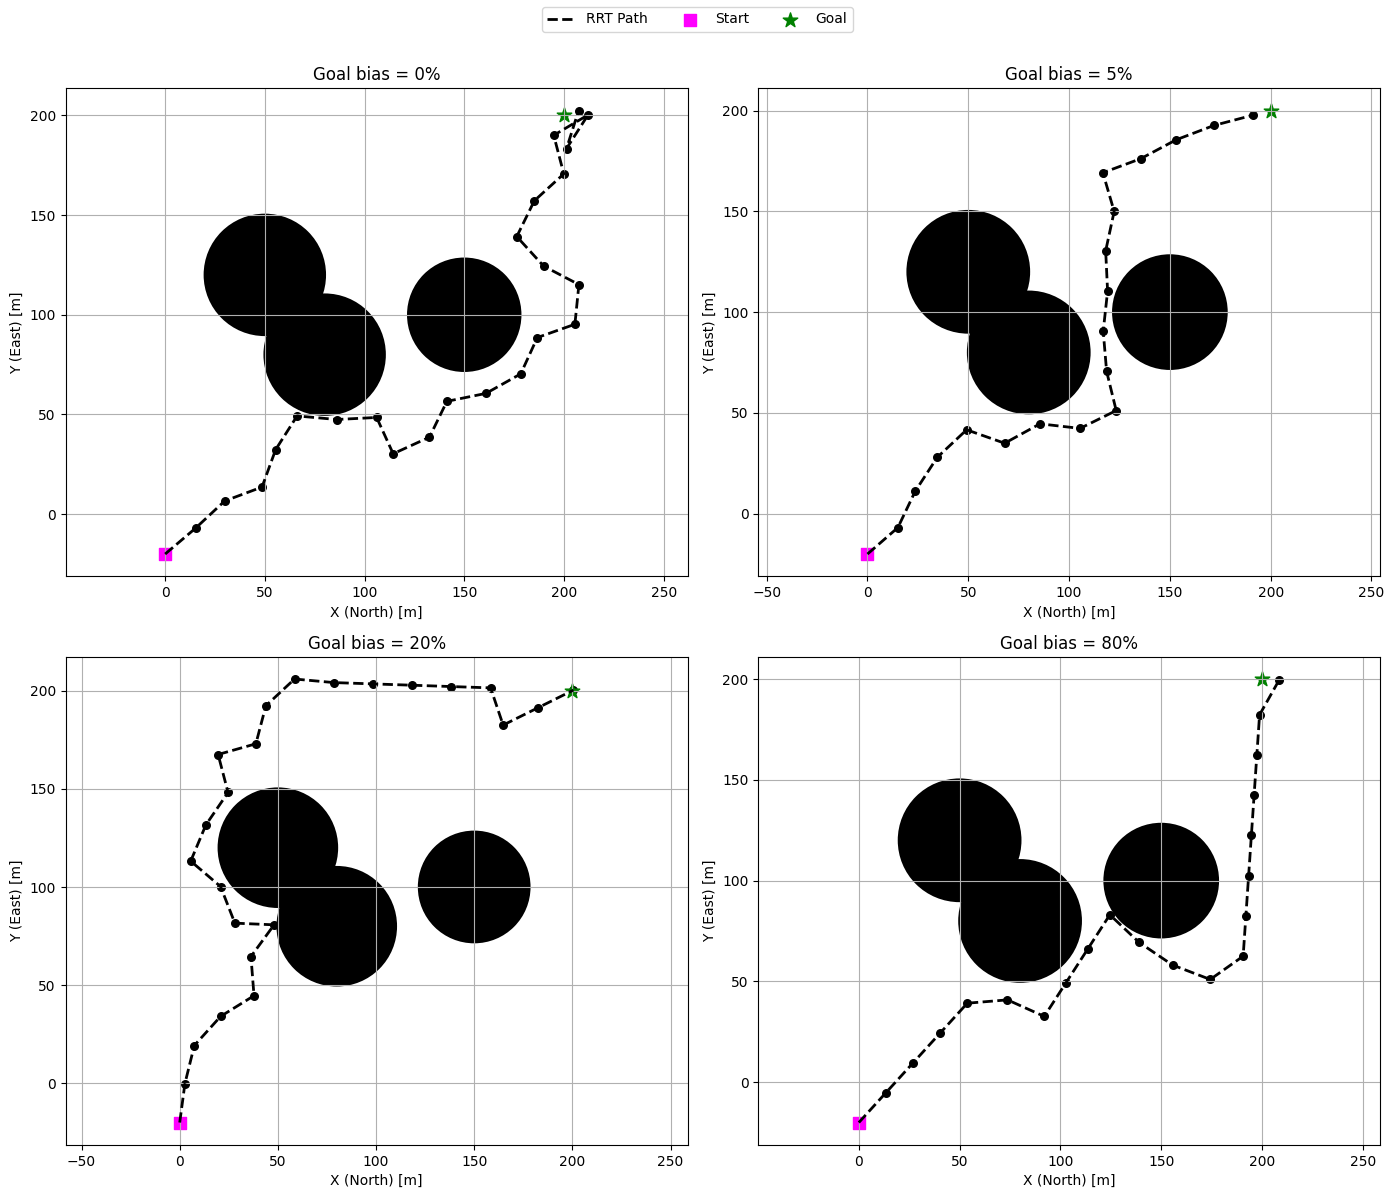

Interpretation:
1) Increasing goal bias usually reduces average planning time at first (0% -> 5% -> 20%).
2) Moderate bias often gives good success and cleaner paths because sampling still explores around obstacles.
3) Very high bias (80%) tends to over-focus toward the goal and under-explore alternatives, which can hurt success in clutter.
4) At high bias, paths can look less robust and more sensitive to random luck near obstacle bottlenecks.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time


# --- Copy of core planner code with goal-bias change ---
class Node:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.parent = None


def get_distance(n1: Node, n2: Node) -> float:
    return np.sqrt((n1.x - n2.x) ** 2 + (n1.y - n2.y) ** 2)


def is_segment_collision_free(p1, p2, obstacles):
    p1, p2 = (p1.x, p1.y), (p2.x, p2.y)
    for (ox, oy, r) in obstacles:
        center = np.array([ox, oy])
        a = np.array(p1)
        b = np.array(p2)

        ab = b - a
        ac = center - a
        denom = np.dot(ab, ab)
        if denom <= 1e-12:
            if np.linalg.norm(a - center) < r:
                return False
            continue

        t = np.dot(ac, ab) / denom
        t = max(0, min(1, t))
        closest_point = a + t * ab

        if np.linalg.norm(closest_point - center) < r:
            return False
    return True


def random_sampling_node(bounds: tuple, goal_node: Node = None, goal_bias_prob: float = 0.0) -> Node:
    """
    Goal-biased sampler:
    - with probability goal_bias_prob -> sample the goal
    - otherwise -> uniform random sample in bounds
    """
    if goal_node is not None and np.random.rand() < goal_bias_prob:
        return Node(goal_node.x, goal_node.y)

    min_x, max_x, min_y, max_y = bounds
    return Node(np.random.uniform(min_x, max_x), np.random.uniform(min_y, max_y))


def get_nearest_node(tree: list[Node], node: Node) -> Node:
    return min(tree, key=lambda n: get_distance(n, node))


def construct_path(node: Node) -> list[Node]:
    path = []
    current = node
    while current is not None:
        path.append(current)
        current = current.parent
    path.reverse()
    return path


def rrt(
    start: tuple,
    goal: tuple,
    obstacles: list[tuple],
    bounds: tuple,
    step_size: float = 20.0,
    max_iter: int = 3000,
    goal_bias_prob: float = 0.0,
) -> list[Node]:
    """
    start: (x, y)
    goal: (x, y, radius)
    bounds: (min_x, max_x, min_y, max_y)
    """
    tree = [Node(start[0], start[1])]
    goal_node = Node(goal[0], goal[1])
    goal_radius = goal[2]

    for _ in range(max_iter):
        random_node = random_sampling_node(bounds, goal_node=goal_node, goal_bias_prob=goal_bias_prob)
        nearest_node = get_nearest_node(tree, random_node)

        theta = np.arctan2(random_node.y - nearest_node.y, random_node.x - nearest_node.x)
        new_x = nearest_node.x + step_size * np.cos(theta)
        new_y = nearest_node.y + step_size * np.sin(theta)
        new_node = Node(new_x, new_y)

        if is_segment_collision_free(nearest_node, new_node, obstacles):
            new_node.parent = nearest_node
            tree.append(new_node)

            if get_distance(new_node, goal_node) <= goal_radius:
                return construct_path(new_node)

    return None


def path_length(path: list[Node]) -> float:
    if path is None or len(path) < 2:
        return np.nan
    return float(sum(get_distance(path[i - 1], path[i]) for i in range(1, len(path))))


def plot_obstacles(ax, obstacles):
    for x_c, y_c, r in obstacles:
        circle = plt.Circle((x_c, y_c), r, color="black", fill=True, linewidth=2)
        ax.add_patch(circle)


def plot_path(ax, path, start, goal, title):
    if path is not None:
        px = [n.x for n in path]
        py = [n.y for n in path]
        ax.plot(px, py, "k--", linewidth=2, label="RRT Path")
        ax.scatter(px, py, c="k", s=30)
    else:
        ax.text(0.5, 0.5, "No path found", transform=ax.transAxes, ha="center", va="center", color="red")

    ax.scatter(start[0], start[1], c="magenta", marker="s", s=80, label="Start")
    ax.scatter(goal[0], goal[1], c="green", marker="*", s=120, label="Goal")
    ax.set_title(title)
    ax.set_xlabel("X (North) [m]")
    ax.set_ylabel("Y (East) [m]")
    ax.axis("equal")
    ax.grid(True)


# --- Experiment setup (same map style as the assignment) ---
start_point = (0.0, -20.0)
goal_region = (200, 200, 10.0)
bounds = (-25, 225, -25, 225)
obstacles = [(80, 80, 30), (50, 120, 30), (150, 100, 28)]
step_size = 20.0
max_iter = 3000

bias_values = [0.00, 0.05, 0.20, 0.80]
runs_per_bias = 5

rows = []
representative_paths = {}

for bias in bias_values:
    for run_id in range(runs_per_bias):
        t0 = time.perf_counter()
        path = rrt(
            start=start_point,
            goal=goal_region,
            obstacles=obstacles,
            bounds=bounds,
            step_size=step_size,
            max_iter=max_iter,
            goal_bias_prob=bias,
        )
        dt = time.perf_counter() - t0

        success = path is not None
        rows.append(
            {
                "goal_bias": bias,
                "run": run_id + 1,
                "success": success,
                "time_s": dt,
                "path_length_m": path_length(path),
                "num_waypoints": len(path) if success else np.nan,
            }
        )

        # Save first successful path for visualization per bias
        if success and bias not in representative_paths:
            representative_paths[bias] = path

results_df = pd.DataFrame(rows)
summary_df = (
    results_df.groupby("goal_bias", as_index=False)
    .agg(
        success_rate=("success", "mean"),
        avg_time_s=("time_s", "mean"),
        std_time_s=("time_s", "std"),
        avg_path_length_m=("path_length_m", "mean"),
        avg_waypoints=("num_waypoints", "mean"),
    )
)
summary_df["success_rate"] = 100.0 * summary_df["success_rate"]

print("RRT goal-bias experiment over 5 runs per bias")
display(results_df.round(3))
print("Summary")
display(summary_df.round(3))

# Plot one representative path for each bias
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, bias in zip(axes.flat, bias_values):
    plot_obstacles(ax, obstacles)

    if bias in representative_paths:
        rep_path = representative_paths[bias]
    else:
        # if no successful run yet, draw one extra trial for a picture
        rep_path = rrt(
            start=start_point,
            goal=goal_region,
            obstacles=obstacles,
            bounds=bounds,
            step_size=step_size,
            max_iter=max_iter,
            goal_bias_prob=bias,
        )

    plot_path(ax, rep_path, start_point, goal_region, title=f"Goal bias = {int(100*bias)}%")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("Interpretation:")
print("1) Increasing goal bias usually reduces average planning time at first (0% -> 5% -> 20%).")
print("2) Moderate bias often gives good success and cleaner paths because sampling still explores around obstacles.")
print("3) Very high bias (80%) tends to over-focus toward the goal and under-explore alternatives, which can hurt success in clutter.")
print("4) At high bias, paths can look less robust and more sensitive to random luck near obstacle bottlenecks.")

From your current run:

1. Success rate: all four biases got 100% in this map for these 5 trials.
2. Execution time trend: 0% was slowest on average, 5% and 20% were faster, and 80% was not consistently better than moderate bias.
3. Path shape:
- 0% looks more exploratory and jagged.
- 5% often gives a cleaner compromise.
- 20% can be very fast but may still produce detours depending on random samples.
- 80% tends to over-focus toward the goal direction, which can be risky around obstacle bottlenecks.

Important interpretation for your writeup:
- In your specific experiment, 80% still succeeded, but that does not mean it is generally best.
- In more cluttered environments or tighter passages, very high goal bias often hurts robustness because exploration is reduced too much.

If you want, I can add one extra block to the same cell to run, say, 30-50 trials per bias so your conclusion is statistically stronger for the report.

Made changes.

Yes. The main issue is that the planner and the vehicle do not obey the same model.

RRT/RRT* in this notebook plans as if the USV were a point that can:
1. change heading instantly,
2. move exactly along straight segments,
3. stop and redirect with no inertia,
4. ignore turning radius, sway, and actuator limits.

But the Otter in simulation is dynamic, so it has inertia and limited yaw response. That means when the geometric path has sharp corners or closely spaced waypoints, the vehicle often cuts the corner, overshoots, or arrives late. As a result, it may fail to stay inside `radius_acceptance` reliably at each waypoint, especially near tight turns or around obstacles. In short: the kinematic planner gives a path that is collision-free for a point mass, but not necessarily easy or even safe for the real vehicle to track.

For the second part, if you want RRT/RRT* to generate paths the Otter can follow more easily, add constraints that encode maneuverability:

1. In `Extend Towards`:
- Limit maximum heading change between consecutive segments.
- Enforce a minimum turning radius.
- Prefer forward-progress motions that are smooth instead of abrupt zig-zags.
- Use shorter extensions in cluttered regions or when curvature would become too high.

2. In `is_segment_collision_free`:
- Inflate obstacles by a safety margin to account for tracking error and vehicle size.
- Reject segments that pass too close to obstacles even if the centerline is technically collision-free.
- Check not only the segment itself, but whether the transition from the previous segment to the new one is dynamically feasible.
- Optionally check a curved connection, not just a straight line, since the boat cannot instantly rotate onto a new heading.

A strong short answer for your notebook would be:

“The kinematic planner assumes ideal motion, so it can produce paths with sharp turns and tightly spaced waypoints that a real Otter USV cannot follow exactly. Because of inertia and limited yaw authority, the vehicle may overshoot corners and leave the waypoint acceptance circle before settling. To make planned paths easier to track, I would add dynamic-feasibility constraints such as a minimum turning radius, a maximum allowed heading change between segments, and inflated obstacle clearances to account for tracking error. I would also modify the extension step to prefer smoother connections instead of purely straight-line point-mass motions.”

If you want, I can also write this directly into the analysis cell in a notebook-ready form.